## Eight School example for hierarchical inference

Fundamental model to explain hierarchical Bayesian inference going back to (Rubin, 1981). See for example implementation in [PyMC](https://www.pymc.io/projects/examples/en/latest/diagnostics_and_criticism/Diagnosing_biased_Inference_with_Divergences.html), example with [TensorFlow](https://www.tensorflow.org/probability/examples/Eight_Schools) or this [blog post](https://statmodeling.stat.columbia.edu/2014/01/21/everything-need-know-bayesian-statistics-learned-eight-schools/)

## Question
The driving question is to assess the effectiveness of a program to improve students’ performance on the Scholastic Aptitude Test (SAT). This program was introduced in 8 schools and the result was an estimated of the mean increase in score ($y$) and the standard error ($\sigma$) per school. Now, the std error is larger than the effect in most schools but the `same course` was taught in each school, so all estimates should be estimates of the same effectiveness. So we cannot simply take the best case outcome (e.g. for the first school). Also, we cannot simply average the effects as there are differences between schools (different teachers and students).

So the idea going back to Rubin was to assume that each school's true improvement $\theta_n$ is drawn from a normal distribution (unknown mean $\mu$ and std $\tau$) and that the actually observed improvement $y$ is sampled again from a normal distribution (mean equal to true improvement $\theta_n$ and std given by measured error $\sigma$$).


## Model
- true improvement: $\theta_n \sim \mathcal{N}(\mu, \tau)$
- measured improvement: $y \sim \mathcal{N}(\theta_n, \sigma)$
- priors: 
    - $\mu \sim \mathcal{N}(0,5)$
    - $\tau \sim \text{HalfCauchy}(0,5)$ (PyMC) or $\log(\tau)\sim\mathcal{N}(0,5)$ (TensorFlow)

In [1]:
using Pkg
Pkg.activate(dirname(@__DIR__))
Pkg.instantiate()

using MonteCarloX
using Random
using Plots
using Statistics
using Distributions

  Activating project at `~/.julia/dev/MonteCarloX.jl/examples`


In [2]:
# data
y = [28.0, 8.0, -3.0, 7.0, -1.0, 1.0, 18.0, 12.0];
σ = [15.0, 10.0, 16.0, 11.0, 9.0, 11.0, 10.0, 18.0];

In [3]:
# sample the posterior distibution P(θ, μ, τ | y, σ) using MonteCarloX
logprior(μ, τ) = logpdf(Normal(0, 5), μ) + logpdf(LogNormal(5, 1), τ) #attention with lognormal, the distribution gets broader with decreasing second parameter
loglikelihood(θ, μ, τ) = sum(logpdf.(Normal.(θ, σ), y)) + sum(logpdf.(Normal(μ, τ), θ))
logposterior(θ, μ, τ) = loglikelihood(θ, μ, τ) + logprior(μ, τ)

logposterior (generic function with 1 method)

In [4]:
struct System
    state :: Vector{Float64}
    state_tmp :: Vector{Float64}
    function System(θ, mu, tau) 
        state = [mu, log(tau), θ...]
        new(state, copy(state))
    end
end
get_mu(state::Vector{Float64}) = state[1]
get_tau(state::Vector{Float64}) = exp(state[2])
get_theta(state::Vector{Float64}) = state[3:end]
logposterior(state::Vector{Float64}) = logposterior(get_theta(state), get_mu(state), get_tau(state))

logposterior (generic function with 2 methods)

In [5]:
# initialize the Markov chain
θ = y
μ = mean(y)
τ = std(y)
# direct
state = (θ, μ, τ)
println("direct: ", logposterior(state...))
#system
sys = System(θ, μ, τ)
println("system: ", logposterior(sys.state))

direct: -67.78664494186803
system: -67.78664494186803


In [6]:
# update range:
Δ = ones(length(sys.state))
# increase range for θ
Δ[3:end] .= 5.0
# decrease range for μ and log(τ)
Δ[1:2] .= 2.0
println("update ranges: ", Δ)

update ranges: [2.0, 2.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]


In [7]:
# define update function for the Markov chain
function update!(sys, alg, Δ)
    #pick random index
    i = rand(rng, 1:length(sys.state))
    # update index in tmp state
    sys.state_tmp[i] += rand(rng, Uniform(-Δ[i], Δ[i]))
    if accept!(alg, sys.state_tmp, sys.state)
        sys.state[i] = sys.state_tmp[i]
    else
        sys.state_tmp[i] = sys.state[i]
    end
end

update! (generic function with 1 method)

In [8]:
# run MC chain
rng = Xoshiro(42)
alg = Metropolis(rng, logposterior)
n_burn = 10_000
for i in 1:n_burn
    update!(sys, alg, Δ)
end
n_samples = 100_000
samples = zeros(length(sys.state), n_samples)
steps_between_samples = 10
i_sample = 1
for i in 1:n_samples*steps_between_samples
    update!(sys, alg, Δ)
    if i % steps_between_samples == 0
        samples[:, i_sample] = sys.state
        i_sample += 1
    end
end
print("acceptance rate: ", acceptance_rate(alg))

acceptance rate: 0.7800623762376238

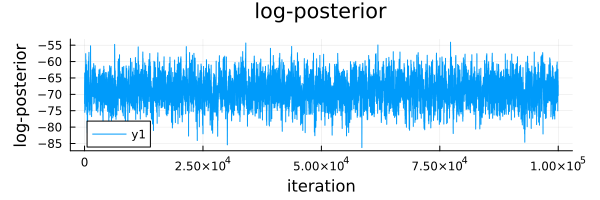

In [9]:
# plot lps
lps=[logposterior(samples[:, i]) for i in 1:n_samples]
plot(lps, title="log-posterior", xlabel="iteration", ylabel="log-posterior", size=(600, 200), margin=5Plots.mm)

In [10]:
# print final state
println("mu: ", get_mu(sys.state))
println("tau: ", get_tau(sys.state))
println("theta: ", get_theta(sys.state))

mu: 3.034803692258897
tau: 13.197086829227064
theta: [19.461283808846844, 8.100283287162961, 9.268420004010379, 4.804494515846258, 0.27672967168563645, -0.5163385862201588, 10.807858000717577, -6.6968243614698055]


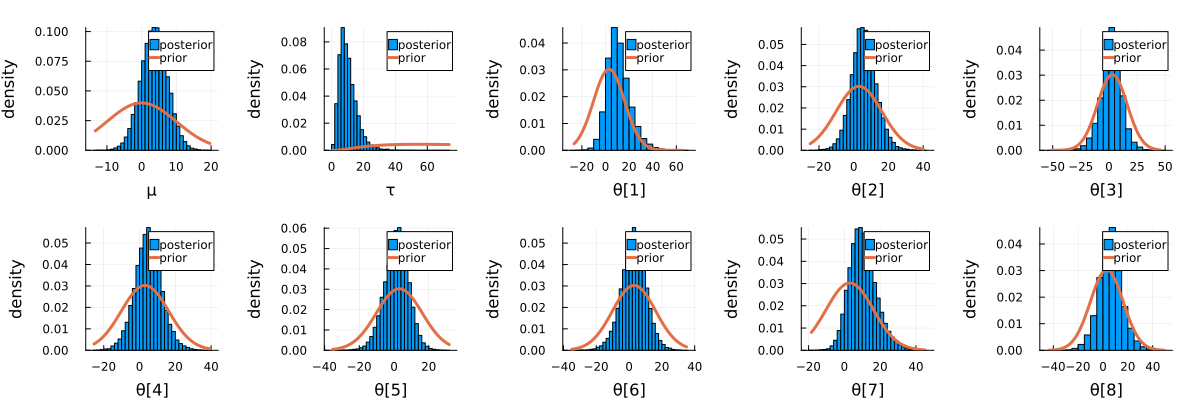

In [11]:
using Plots, Distributions

ps = []   # container for subplots

# ---------- μ ----------
μ_samples = samples[1, :]
p = histogram(μ_samples,
    xlabel="μ",
    ylabel="density",
    normalize=:pdf,
    label="posterior",
    bins=40)

xmin, xmax = extrema(μ_samples)
xs = range(xmin, xmax, length=300)

plot!(p, xs, pdf.(Normal(0,10), xs),
    label="prior",
    lw=3)

push!(ps, p)

# ---------- τ ----------
τ_samples = exp.(samples[2, :])

p = histogram(τ_samples,
    xlabel="τ",
    ylabel="density",
    normalize=:pdf,
    label="posterior",
    bins=40)

xmin, xmax = extrema(τ_samples)
xs = range(xmin, xmax, length=300)

plot!(p, xs, pdf.(LogNormal(5,1), xs),
    label="prior",
    lw=3)

push!(ps, p)

# ---------- θ_i ----------
μ_prior = get_mu(sys.state)
τ_prior = get_tau(sys.state)
θ_prior = Normal(μ_prior, τ_prior)

for i in 1:8
    θ_samples = samples[2 + i, :]

    p = histogram(θ_samples,
        xlabel="θ[$i]",
        ylabel="density",
        normalize=:pdf,
        label="posterior",
        bins=40)

    xmin, xmax = extrema(θ_samples)
    xs = range(xmin, xmax, length=300)

    plot!(p, xs, pdf.(θ_prior, xs),
        label="prior",
        lw=3)

    push!(ps, p)
end

plot(ps..., layout=(2,5), size=(1200,400), margin=5 * Plots.mm)

In [14]:
# now print the median and confidence intervals for μ, τ and θ_i
println("μ: median = ", round(median(μ_samples), digits=2), ", 95% CI = [", round(quantile(μ_samples, 0.025), digits=2), ", ", round(quantile(μ_samples, 0.975), digits=2), "]")
println("τ: median = ", round(median(τ_samples), digits=2), ", 95% CI = [", round(quantile(τ_samples, 0.025), digits=2), ", ", round(quantile(τ_samples, 0.975), digits=2), "]")
for i in 1:8 
    θ_samples = samples[2 + i, :]
    println("θ[$i]: median = ", round(median(θ_samples), digits=2), ", 95% CI = [", round(quantile(θ_samples, 0.025), digits=2), ", ", round(quantile(θ_samples, 0.975), digits=2), "]")
end

μ: median = 3.6, 95% CI = [-3.95, 11.15]
τ: median = 9.25, 95% CI = [2.69, 23.76]
θ[1]: median = 10.04, 95% CI = [-5.11, 33.64]
θ[2]: median = 5.69, 95% CI = [-7.78, 20.53]
θ[3]: median = 2.48, 95% CI = [-17.33, 20.02]
θ[4]: median = 4.84, 95% CI = [-9.99, 20.09]
θ[5]: median = 1.83, 95% CI = [-12.83, 14.51]
θ[6]: median = 3.05, 95% CI = [-12.67, 17.31]
θ[7]: median = 9.82, 95% CI = [-2.77, 26.99]
θ[8]: median = 5.66, 95% CI = [-13.0, 25.57]
